In [1]:
print("""
Pattern Recognition Machine Learning Project -
"CERN Electron Collision Sensor Data Explainability and Purging"

Objective:
1. Predict Invariant Mass (M)
2. Sensor Explainability
3. Sensor Purging
4. Redundant Sensor Prediction

Dataset:
CERN Dielectron Dataset
""")


Pattern Recognition Machine Learning Project -
"CERN Electron Collision Sensor Data Explainability and Purging"

Objective:
1. Predict Invariant Mass (M)
2. Sensor Explainability
3. Sensor Purging
4. Redundant Sensor Prediction

Dataset:
CERN Dielectron Dataset



In [2]:
# Import Required Libraries

# Hide warning messages
import warnings
warnings.filterwarnings("ignore")

# Numerical computing
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset splitting
from sklearn.model_selection import train_test_split

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Display all dataframe columns
pd.set_option("display.max_columns", None)

# Display floating point values up to 3 decimals
pd.set_option("display.float_format", "{:.3f}".format)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# Load Dataset

df = pd.read_csv("../data/raw/dielectron.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [ ]:
# Dataset Dimensions

print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print(f"Memory Usage : {df.memory_usage(deep=True).sum()/1024**2:.2f} MB")

print(f"Dataset Shape : {df.shape}")

Rows : 100000
Columns : 19
Memory Usage : 14.50 MB
Dataset Shape : (100000, 19)


In [7]:
# Dataset Overview

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Run     100000 non-null  int64  
 1   Event   100000 non-null  int64  
 2   E1      100000 non-null  float64
 3   px1     100000 non-null  float64
 4   py1     100000 non-null  float64
 5   pz1     100000 non-null  float64
 6   pt1     100000 non-null  float64
 7   eta1    100000 non-null  float64
 8   phi1    100000 non-null  float64
 9   Q1      100000 non-null  int64  
 10  E2      100000 non-null  float64
 11  px2     100000 non-null  float64
 12  py2     100000 non-null  float64
 13  pz2     100000 non-null  float64
 14  pt2     100000 non-null  float64
 15  eta2    100000 non-null  float64
 16  phi2    100000 non-null  float64
 17  Q2      100000 non-null  int64  
 18  M       99915 non-null   float64
dtypes: float64(15), int64(4)
memory usage: 14.5 MB


In [5]:
# Preview Dataset

print("First Five Rows")
display(df.head())

print("\nLast Five Rows")
display(df.tail())

First Five Rows


,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,147115,366639895,58.714,-7.311,10.531,-57.297,12.820,-2.203,2.178,1,11.284,-1.032,-1.881,-11.078,2.145,-2.344,-2.073,-1,8.948
1,147115,366704169,6.612,-4.152,-0.580,-5.113,4.192,-1.028,-3.003,-1,17.149,-11.713,5.045,11.465,12.754,0.808,2.735,1,15.893
2,147115,367112316,25.542,-11.481,2.042,22.725,11.661,1.420,2.966,1,15.820,-1.473,2.259,-15.589,2.697,-2.455,2.149,1,38.388
3,147115,366952149,65.396,7.512,11.887,63.866,14.062,2.218,1.007,1,25.127,4.088,2.596,24.656,4.843,2.330,0.566,-1,3.729
4,147115,366523212,61.450,2.953,-14.623,-59.612,14.918,-2.094,-1.372,-1,13.887,-0.278,-2.426,-13.671,2.441,-2.424,-1.685,-1,2.747



Last Five Rows


,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
99995,146511,522575834,12.313,-10.658,5.164,3.369,11.843,0.281,2.690,-1,1.802,0.669,-1.584,0.538,1.720,0.308,-1.171,1,8.448
99996,146511,522786431,18.464,7.855,15.133,-7.087,17.050,-0.405,1.092,1,14.691,-1.418,-2.281,-14.444,2.686,-2.384,-2.127,1,20.715
99997,146511,522906124,4.186,-3.273,-0.309,-2.590,3.288,-0.723,-3.048,1,72.817,-11.075,-9.282,-71.369,14.450,-2.300,-2.444,-1,12.713
99998,146511,523243830,54.462,11.353,11.881,51.924,16.433,1.868,0.808,-1,8.587,0.378,3.078,8.007,3.101,1.677,1.449,1,4.697
99999,146511,524172389,7.640,0.886,5.479,-5.250,5.550,-0.843,1.410,1,52.109,16.808,-4.605,49.108,17.427,1.759,-0.267,-1,36.504


In [31]:
# Descriptive Statistics

display(df.describe())

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M,Total_Energy
count,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000
mean,147935.538,495753204.078,36.460,0.136,0.183,-1.512,14.418,-0.064,0.022,-0.005,44.031,-0.003,0.126,-1.590,13.806,-0.073,0.022,-0.004,30.021,80.490
std,920.342,403818165.601,41.223,13.409,13.475,51.623,12.392,1.463,1.800,1.000,46.763,13.131,13.173,61.458,12.465,1.739,1.817,1.000,25.256,57.369
min,146511.000,6414.000,0.378,-250.587,-126.079,-840.987,0.220,-4.165,-3.142,-1.000,0.472,-233.730,-145.651,-655.396,0.027,-7.065,-3.142,-1.000,2.000,3.314
25%,147114.000,202321084.750,8.471,-5.237,-5.282,-15.900,3.773,-1.285,-1.527,-1.000,11.070,-4.794,-4.606,-22.062,3.738,-1.893,-1.556,-1.000,12.446,37.785
50%,147929.000,390259554.000,21.740,0.142,0.100,-0.314,12.972,-0.062,0.035,-1.000,25.292,-0.035,0.084,-0.694,11.692,-0.137,0.027,-1.000,21.284,70.200
75%,149011.000,634089113.250,50.064,5.719,5.652,13.232,20.026,1.145,1.563,1.000,66.985,4.820,5.064,19.045,19.602,1.769,1.597,1.000,39.029,105.656
max,149182.000,1791247487.000,850.602,134.539,147.467,760.096,265.578,2.623,3.141,1.000,948.375,227.330,166.283,935.558,281.654,3.061,3.141,1.000,109.999,951.779


In [9]:
# Check missing values
missing = pd.DataFrame({

    "Missing": df.isnull().sum(),

    "Percentage": 100 * df.isnull().mean()

})

missing = missing[missing["Missing"] > 0]

display(missing)


,Missing,Percentage
M,85,0.085


In [10]:
# Identify duplicate observations.

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 23


In [11]:
# Invalid Value Check
# Count infinite values present in the dataset.

infinite_values = np.isinf(
    df.select_dtypes(include=np.number)
).sum()

display(
    infinite_values.to_frame(
        name="Infinite Values"
    )
)

,Infinite Values
Run,0
Event,0
E1,0
px1,0
py1,0
pz1,0
pt1,0
eta1,0
phi1,0
Q1,0


In [12]:
# Charge Distribution
# Display unique values present in the electron charge variables.
print("Unique values in Q1 :", sorted(df["Q1"].unique()))

print("Unique values in Q2 :", sorted(df["Q2"].unique()))

Unique values in Q1 : [np.int64(-1), np.int64(1)]
Unique values in Q2 : [np.int64(-1), np.int64(1)]


In [13]:
# Distribution Statistics
# Measure skewness and kurtosis for every numerical feature.

distribution = pd.DataFrame({

    "Skewness": df.skew(numeric_only=True),

    "Kurtosis": df.kurtosis(numeric_only=True)

}).sort_values(

    by="Skewness",

    key=abs,

    ascending=False

)

display(distribution)

,Skewness,Kurtosis
E1,2.513,12.347
E2,2.210,9.925
pt2,1.994,9.960
pt1,1.741,7.293
M,1.301,0.777
Event,1.275,1.038
px1,-0.119,5.343
pz2,0.074,5.294
px2,-0.063,7.259
eta2,0.054,-1.552


In [14]:
# Distribution of Invariant Mass (Target Variable)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="M",
    bins=50,
    kde=True
    color="steelblue"
)

plt.title("Distribution of Invariant Mass (M)")
plt.xlabel("Invariant Mass")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (110646365.py, line 9)

In [ ]:
# Summary Statistics for Invariant Mass

print(df["M"].describe())
print()
print(f"Median : {df['M'].median():.3f}")
print(f"Variance : {df['M'].var():.3f}")
print("\nSkewness :", round(df["M"].skew(), 3))
print("Kurtosis :", round(df["M"].kurtosis(), 3))

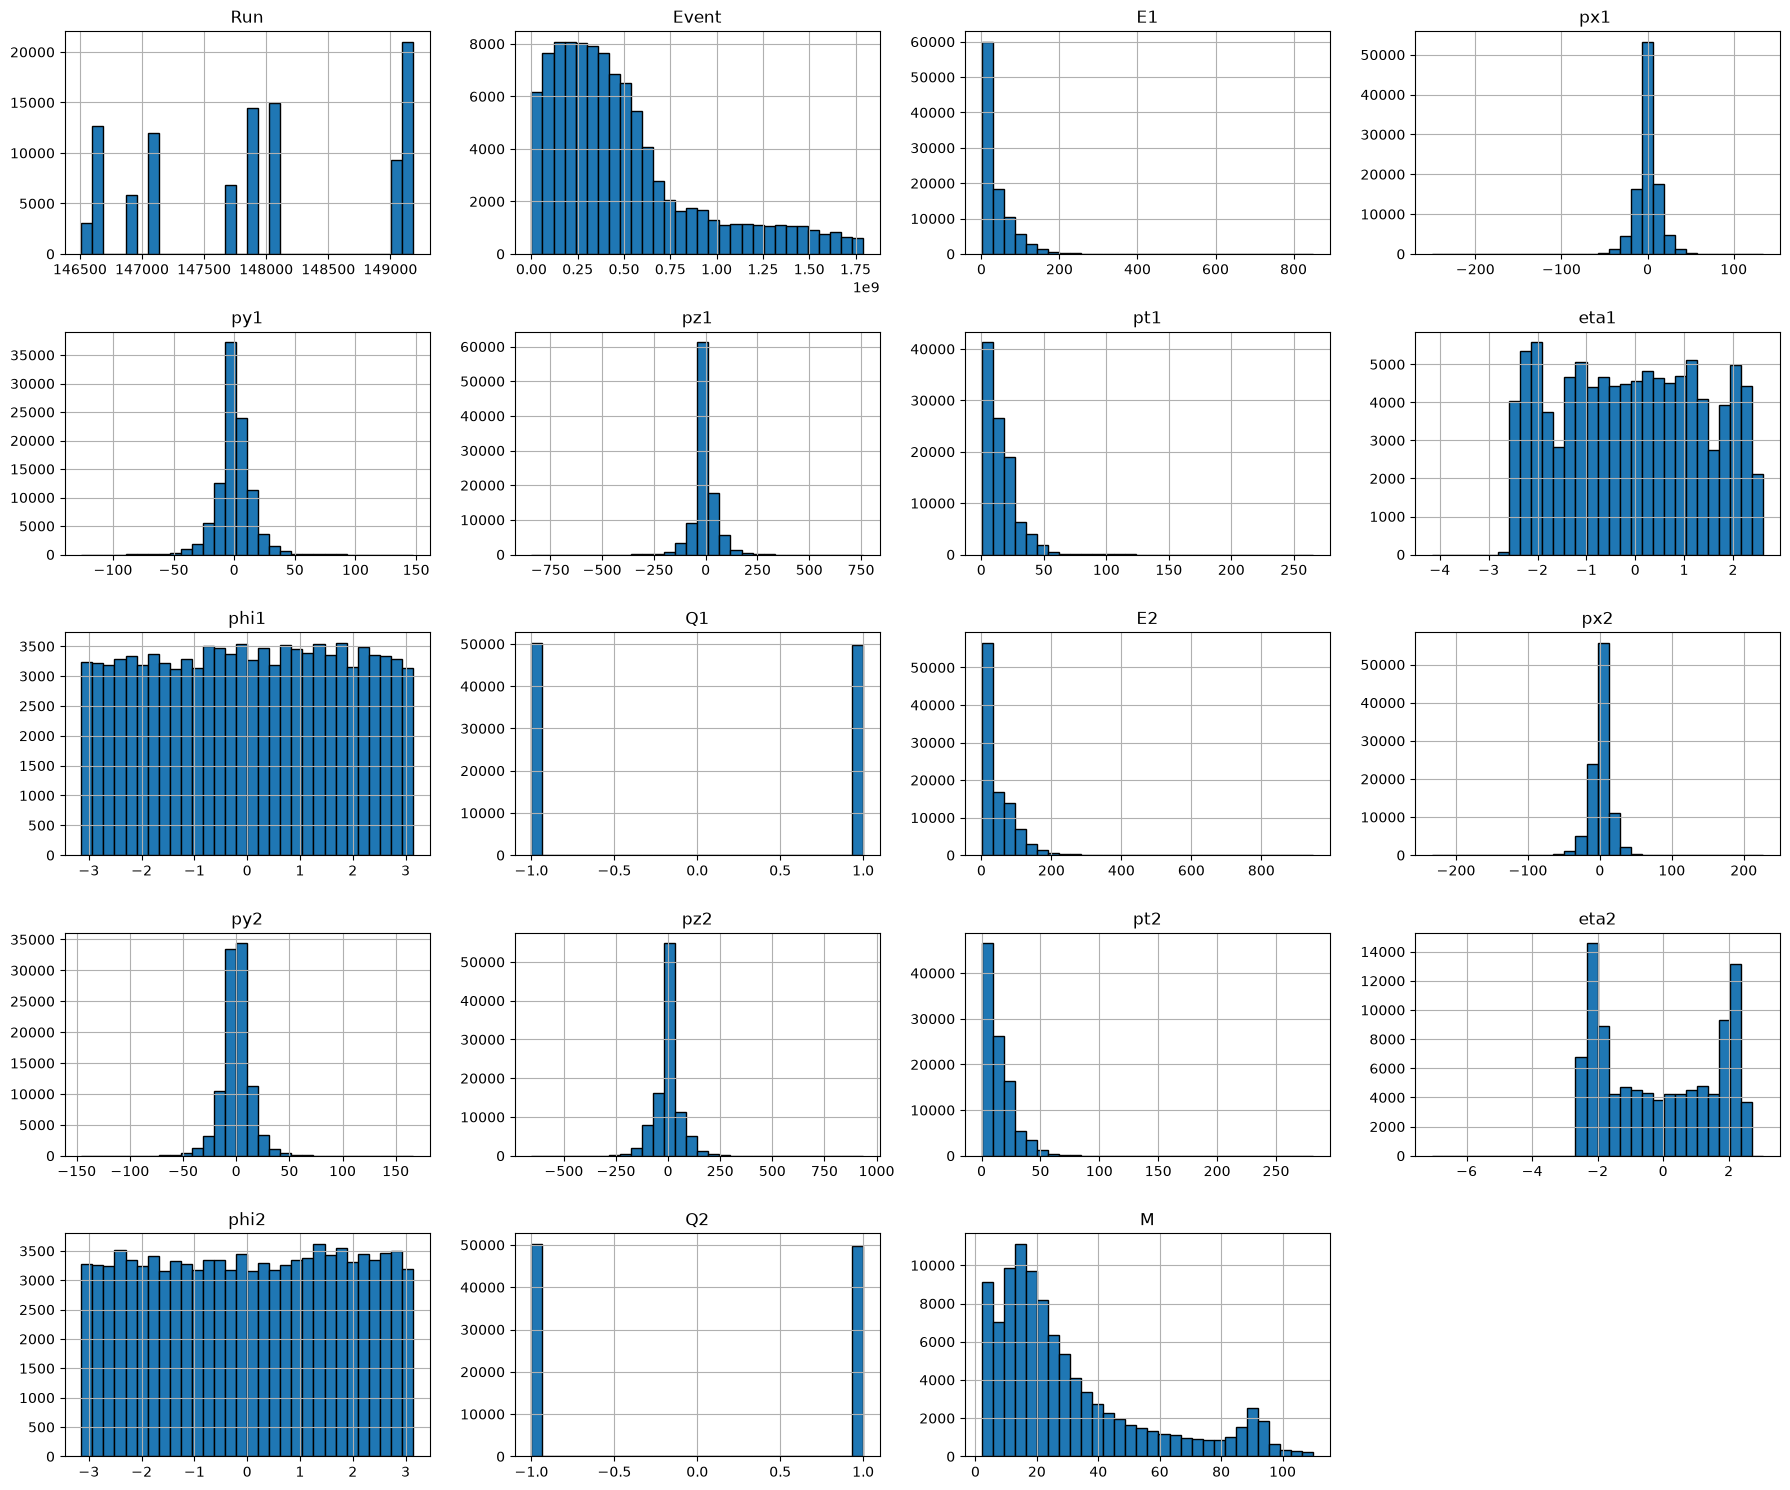

In [15]:
# Histograms for Numerical Features

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(
    figsize=(18, 15),
    bins=30,
    edgecolor="black"
)

plt.tight_layout()
plt.show()

In [16]:
# Correlation Matrix

correlation = df.corr(numeric_only=True)

display(correlation)

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
Run,1.000,0.178,0.093,-0.001,0.003,-0.008,0.154,-0.005,-0.001,0.002,0.099,0.003,-0.005,0.003,0.152,0.005,0.000,0.002,0.129
Event,0.178,1.000,0.041,-0.001,0.001,-0.003,0.059,-0.005,-0.000,-0.006,0.042,-0.001,-0.004,0.002,0.059,0.003,-0.004,0.004,0.052
E1,0.093,0.041,1.000,0.006,0.034,-0.043,0.716,-0.021,0.021,0.019,-0.154,-0.010,-0.020,-0.000,-0.139,-0.008,-0.007,-0.001,0.285
px1,-0.001,-0.001,0.006,1.000,-0.008,-0.013,-0.005,-0.010,-0.007,-0.005,-0.005,-0.326,0.001,-0.005,-0.004,-0.004,0.002,0.006,0.006
py1,0.003,0.001,0.034,-0.008,1.000,-0.010,0.014,-0.012,0.594,-0.003,0.002,0.003,-0.333,0.000,0.003,-0.002,-0.222,0.004,0.008
pz1,-0.008,-0.003,-0.043,-0.013,-0.010,1.000,-0.011,0.772,-0.011,-0.003,0.002,0.003,-0.002,0.206,0.006,0.229,0.004,0.001,0.012
pt1,0.154,0.059,0.716,-0.005,0.014,-0.011,1.000,0.013,0.005,0.018,-0.170,-0.008,-0.020,0.012,-0.032,0.005,-0.007,-0.003,0.437
eta1,-0.005,-0.005,-0.021,-0.010,-0.012,0.772,0.013,1.000,-0.013,-0.002,-0.009,-0.001,-0.004,0.224,-0.005,0.246,0.002,0.003,0.017
phi1,-0.001,-0.000,0.021,-0.007,0.594,-0.011,0.005,-0.013,1.000,0.001,0.002,0.003,-0.217,0.000,-0.001,0.001,-0.134,-0.002,0.002
Q1,0.002,-0.006,0.019,-0.005,-0.003,-0.003,0.018,-0.002,0.001,1.000,-0.012,-0.003,0.003,-0.005,-0.009,-0.004,-0.002,-0.141,0.006


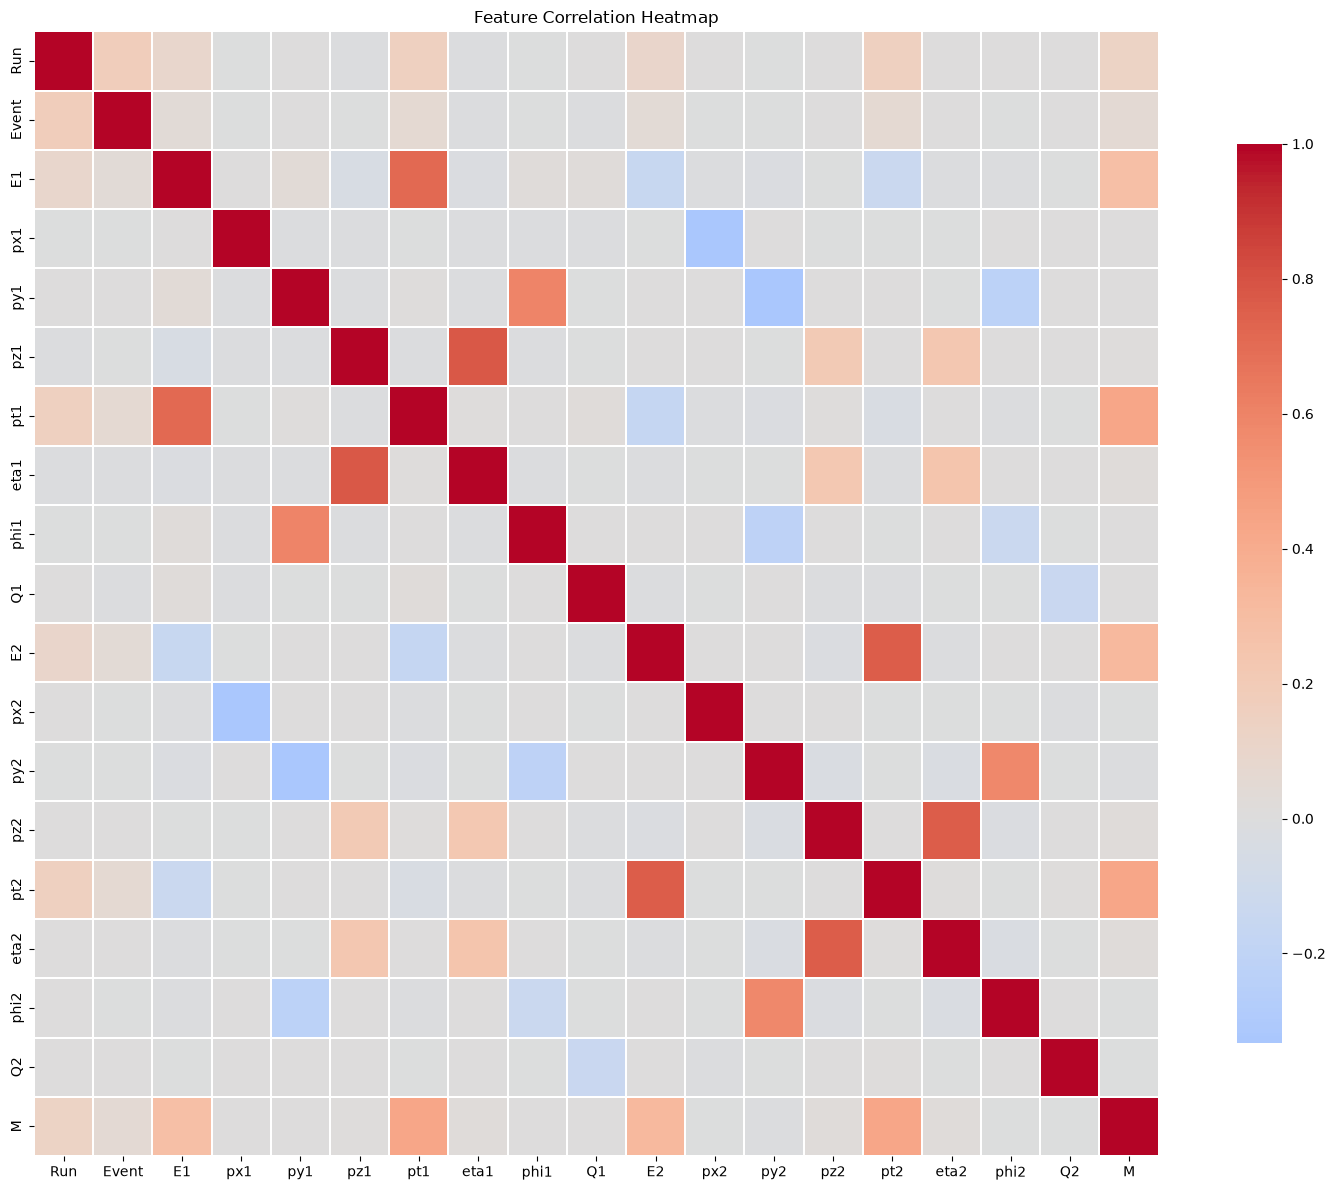

In [17]:
# Correlation Heatmap

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

In [18]:
# Correlation with Invariant Mass

display(
    target_corr
    .to_frame(name="Correlation")
    .sort_values(
        by="Correlation",
        key=abs,
        ascending=False
    )
)

NameError: name 'target_corr' is not defined

In [ ]:
# Top 10 Features Correlated with Invariant Mass

plt.figure(figsize=(8, 6))

sns.barplot(
    x=target_corr.head(10).values,
    y=target_corr.head(10).index
)

plt.title("Top Features Correlated with Invariant Mass")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
# Boxplots for Numerical Features

plt.figure(figsize=(18, 12))

df[numeric_cols].boxplot(
    rot=90,
    grid=False
)

plt.title("Boxplots of Numerical Features")

plt.tight_layout()
plt.show()

In [ ]:
# Outlier Detection Using IQR

outliers = {}

for column in numeric_cols:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = df[
        (df[column] < lower) |
        (df[column] > upper)
    ].shape[0]

    outliers[column] = count

outlier_df = pd.DataFrame.from_dict(
    outliers,
    orient="index",
    columns=["Outliers"]
)

outlier_df["Percentage"] = (
    outlier_df["Outliers"] / len(df)
) * 100

display(
    outlier_df.sort_values(
        by="Outliers",
        ascending=False
    )
)

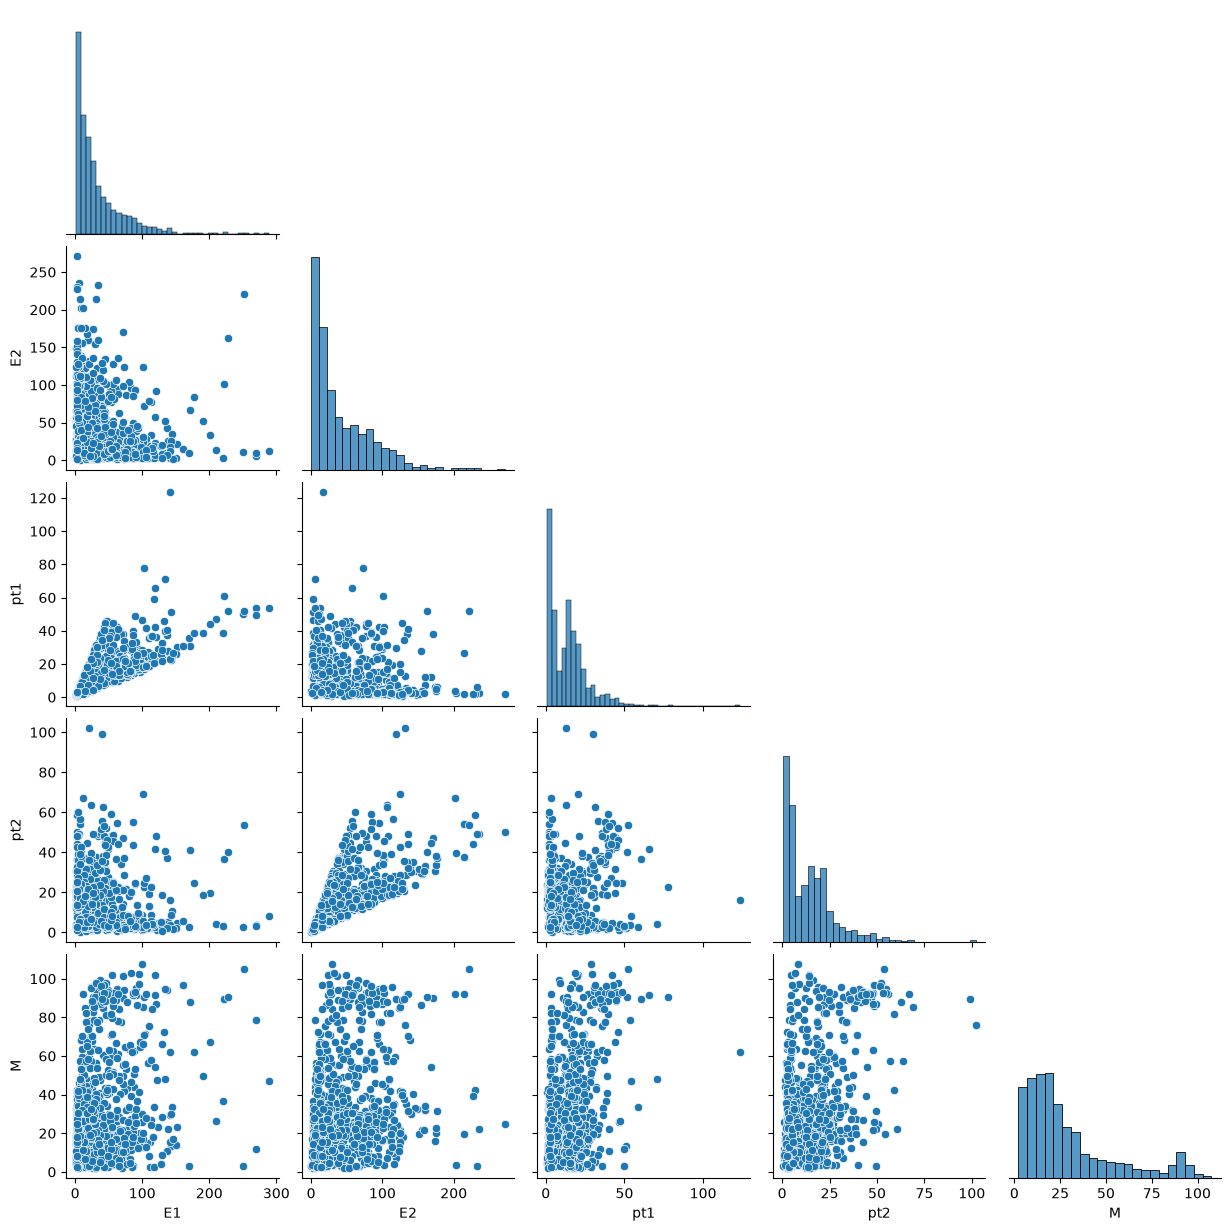

In [19]:
# Pairwise Relationships

selected_features = [
    "E1",
    "E2",
    "pt1",
    "pt2",
    "M"
]

sns.pairplot(
    df[selected_features].sample(
        n=1000,
        random_state=42
    ),
    corner=True
)

plt.show()

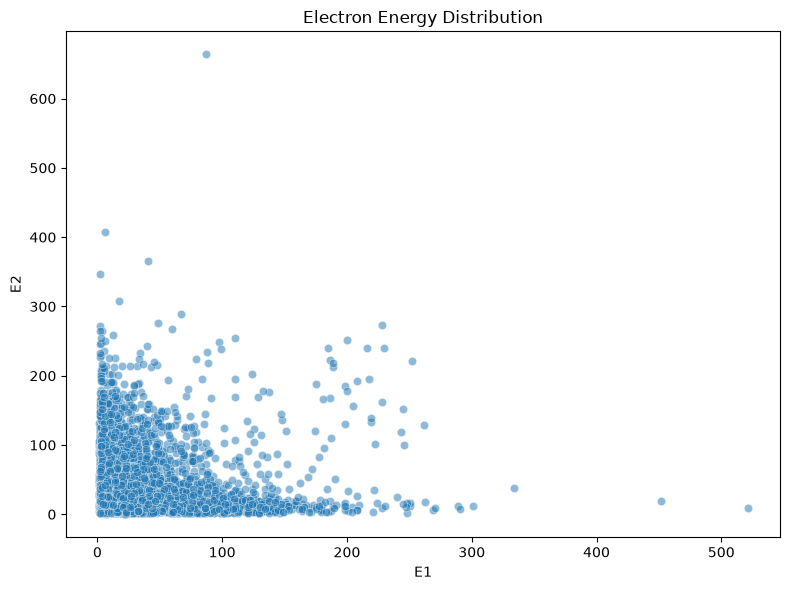

In [20]:
# Relationship Between Electron Energies

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df.sample(
        n=5000,
        random_state=42
    ),
    x="E1",
    y="E2",
    alpha=0.5
)

plt.title("Electron Energy Distribution")
plt.xlabel("E1")
plt.ylabel("E2")

plt.tight_layout()
plt.show()

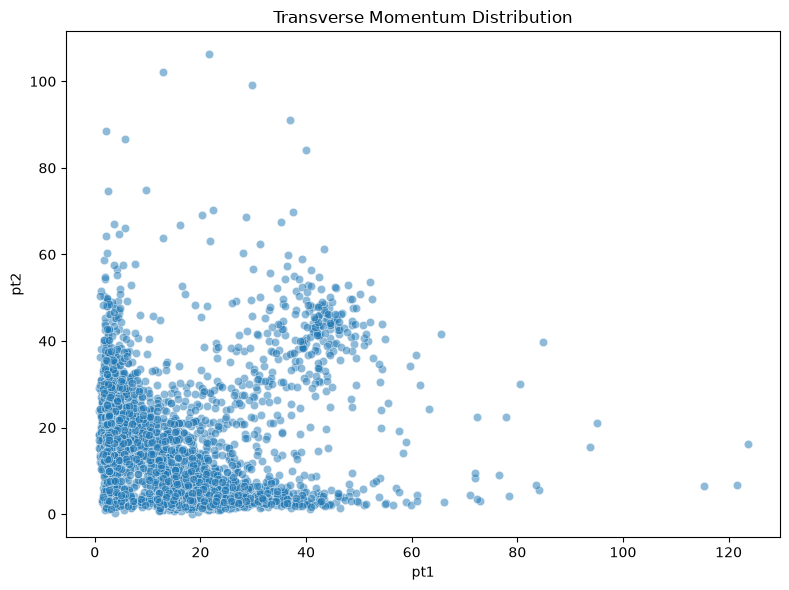

In [21]:
# Relationship Between Transverse Momenta

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df.sample(
        n=5000,
        random_state=42
    ),
    x="pt1",
    y="pt2",
    alpha=0.5
)

plt.title("Transverse Momentum Distribution")
plt.xlabel("pt1")
plt.ylabel("pt2")

plt.tight_layout()
plt.show()

In [22]:
# Remove Duplicate Records

duplicates = df.duplicated().sum()

print("Duplicate Rows Before Removal :", duplicates)

df = df.drop_duplicates()

print("Duplicate Rows After Removal :", df.duplicated().sum())

Duplicate Rows Before Removal : 23
Duplicate Rows After Removal : 0


In [23]:
# Handle Missing Values

print(df.isnull().sum())

df = df.dropna()

print("\nRemaining Missing Values")

print(df.isnull().sum().sum())

Run       0
Event     0
E1        0
px1       0
py1       0
pz1       0
pt1       0
eta1      0
phi1      0
Q1        0
E2        0
px2       0
py2       0
pz2       0
pt2       0
eta2      0
phi2      0
Q2        0
M        85
dtype: int64

Remaining Missing Values
0


In [24]:
# Replace Infinite Values

df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

df.dropna(inplace=True)

print("Dataset Shape :", df.shape)

Dataset Shape : (99892, 19)


In [25]:
# Generate Physics-Inspired Features

# Total Energy
df["Total_Energy"] = df["E1"] + df["E2"]

# Total Momentum
df["Total_Momentum"] = np.sqrt(
    (df["px1"] + df["px2"])**2 +
    (df["py1"] + df["py2"])**2 +
    (df["pz1"] + df["pz2"])**2
)

# Momentum Magnitude of Electron 1
df["Momentum1"] = np.sqrt(
    df["px1"]**2 +
    df["py1"]**2 +
    df["pz1"]**2
)

# Momentum Magnitude of Electron 2
df["Momentum2"] = np.sqrt(
    df["px2"]**2 +
    df["py2"]**2 +
    df["pz2"]**2

)

# Total Transverse Momentum
df["Total_PT"] = df["pt1"] + df["pt2"]

# Energy Difference
df["Energy_Difference"] = abs(
    df["E1"] - df["E2"]
)

# Momentum Difference
df["Momentum_Difference"] = abs(
    df["Momentum1"] - df["Momentum2"]
)

# Transverse Momentum Difference
df["PT_Difference"] = abs(
    df["pt1"] - df["pt2"]
)

# Eta Difference
df["Eta_Difference"] = abs(
    df["eta1"] - df["eta2"]
)

# Phi Difference
df["Phi_Difference"] = abs(
    df["phi1"] - df["phi2"]
)

# Charge Product
df["Charge_Product"] = df["Q1"] * df["Q2"]

# Charge Difference
df["Charge_Difference"] = abs(
    df["Q1"] - df["Q2"]
)

# Cosine of Angle Between Electrons
p1 = np.sqrt(
    df["px1"]**2 +
    df["py1"]**2 +
    df["pz1"]**2
)

p2 = np.sqrt(
    df["px2"]**2 +
    df["py2"]**2 +
    df["pz2"]**2
)

dot = (
    df["px1"]*df["px2"] +
    df["py1"]*df["py2"] +
    df["pz1"]*df["pz2"]
)

df["Cos_Theta"] = dot / (p1 * p2)

KeyError: 'px1'

In [26]:
# Display Engineered Features

engineered_features = [

    "Total_Energy",
    "Total_Momentum",
    "Momentum1",
    "Momentum2",
    "Total_PT",
    "Energy_Difference",
    "Momentum_Difference",
    "PT_Difference",
    "Eta_Difference",
    "Phi_Difference",
    "Charge_Product",
    "Charge_Difference",
    "Cos_Theta"

]

display(df[engineered_features].head())

KeyError: "['Total_Momentum', 'Momentum1', 'Momentum2', 'Total_PT', 'Energy_Difference', 'Momentum_Difference', 'PT_Difference', 'Eta_Difference', 'Phi_Difference', 'Charge_Product', 'Charge_Difference', 'Cos_Theta'] not in index"

In [27]:
# Create Feature Matrix and Target Variable

X = df.drop(columns=["M"])

y = df["M"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (99892, 19)
Target Shape : (99892,)


In [28]:
# Split Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 79913
Testing Samples : 19979


In [29]:
# Standardize Features

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(

    scaler.fit_transform(X_train),

    columns=X_train.columns,

    index=X_train.index

)

X_test_scaled = pd.DataFrame(

    scaler.transform(X_test),

    columns=X_test.columns,

    index=X_test.index

)

print("Feature Scaling Completed")

Feature Scaling Completed


In [30]:
# Save Processed Datasets

import os

os.makedirs("../data/processed", exist_ok=True)

X_train.to_csv("../data/processed/X_train.csv", index=False)
X_test.to_csv("../data/processed/X_test.csv", index=False)

X_train_scaled.to_csv(
    "../data/processed/X_train_scaled.csv",
    index=False
)

X_test_scaled.to_csv(
    "../data/processed/X_test_scaled.csv",
    index=False
)

y_train.to_csv(
    "../data/processed/y_train.csv",
    index=False
)

y_test.to_csv(
    "../data/processed/y_test.csv",
    index=False
)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.
